# Clasificación de Supervivencia en el Titanic — 8 modelos de ML (Semana 2)

**Maestría en Inteligencia Artificial Aplicada — UIDE**
**Asignatura:** Aprendizaje Automático Estadístico — MIA-B
**Docente:** PhD. Iván García Santillán
**Semana 2 — Componente práctico (Práctica Grupal — Grupo 2)**

**Integrantes (Grupo 2):**
- Gualli Ramírez, Jonathan Fabricio
- Quizamánchuro Fuel, Jorge Armando
- Salazar Gamboa, Raúl Marcelo

---

## Resumen del trabajo

Este notebook aplica el **mismo flujo de tres fases** del notebook de Cáncer de Mama (de Marcelo)
sobre el dataset del **Titanic**, para predecir la **supervivencia** de los pasajeros. El Titanic es
un dataset "sucio" (nulos, categóricas, redundancias) por lo que **el preprocesamiento es mucho más
rico**, que es justamente su valor didáctico.

Se comparan **8 modelos**, cada uno en versión *baseline* y *mejorada* (`GridSearchCV` /
`RandomizedSearchCV` con `scoring="recall"`): Regresión Logística, KNN, Naive Bayes, Random Forest,
Árbol de Decisión, SVM, Gradient Boosting y **Red Neuronal (Keras)**.

> **Clase positiva = `survived = 1` (Sobrevivió).** Priorizamos el **Recall**: en un contexto de
> rescate, el Falso Negativo (predecir que no sobrevivió alguien que sí podía sobrevivir) es el error
> más costoso, igual que en el dataset clínico el FN era el más grave.

## 1. Configuración del entorno y carga de librerías

`SEED = 42` en todo lo que acepte `random_state`. Paleta del equipo: `#2a9d8f` (no sobrevivió) y
`#e76f51` (sobrevivió). Las funciones de evaluación son **las mismas** que las de Marcelo.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # silencia logs de TensorFlow
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      RandomizedSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Paleta del equipo
COLOR_NEG = "#2a9d8f"   # No sobrevivió (clase negativa)
COLOR_POS = "#e76f51"   # Sobrevivió (clase positiva)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Rutas relativas (mismo esquema que el resto del repo)
NB_DIR = Path.cwd()
PROJ_DIR = NB_DIR.parent            # semana-2/
MODELS_DIR = PROJ_DIR / "models"
OUT_DIR = PROJ_DIR / "outputs"
DATA_DIR = PROJ_DIR / "data"
MODELS_DIR.mkdir(exist_ok=True); OUT_DIR.mkdir(exist_ok=True)

print(f"TensorFlow {tf.__version__} | Keras {keras.__version__}")
print(f"Modelos -> {MODELS_DIR}")

TensorFlow 2.21.0 | Keras 3.14.1
Modelos -> /Users/jorgequizamanchuro/Documents/Proyectos/UIDE/UIDE-Aprendizaje-Automatico-Estadistico/semana-2/models


---
# Fase I — Preprocesamiento

A diferencia del WBCD (curado), el Titanic exige limpiar nulos, eliminar columnas con fuga de
información, imputar y codificar. Aquí está el grueso del trabajo de un científico de datos.

## 2. Carga y exploración inicial

Cargamos el Titanic con **seaborn** (`sns.load_dataset('titanic')`), con respaldo a una copia local.
La variable objetivo es `survived`: **1 = Sobrevivió (clase positiva)**, 0 = No sobrevivió.

**Justificación de la clase positiva:** queremos *detectar a quien sobrevive*; en un contexto de
rescate, el Falso Negativo (predecir que no sobrevivió alguien que sí lo hizo) podría significar **no
enviar ayuda a tiempo**. Por eso optimizamos el **Recall**.

In [2]:
try:
    df = sns.load_dataset("titanic")
except Exception:
    df = pd.read_csv(DATA_DIR / "titanic_seaborn.csv")

print(f"Dimensiones: {df.shape[0]} pasajeros x {df.shape[1]} columnas")
print("\nDistribución de la clase objetivo (survived):")
print(df["survived"].value_counts().rename({0: "No sobrevivió", 1: "Sobrevivió"}))
print("\nTipos de datos:")
print(df.dtypes)
df.head()

Dimensiones: 891 pasajeros x 15 columnas

Distribución de la clase objetivo (survived):
survived
No sobrevivió    549
Sobrevivió       342
Name: count, dtype: int64

Tipos de datos:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Eliminación de columnas irrelevantes / con fuga de información

La versión de seaborn ya no trae `name`, `ticket` ni `cabin` (identificadores). Eliminamos las
columnas **derivadas o con fuga de información**:

- `alive`: es **literalmente** `survived` en texto → **fuga directa del target**.
- `class`: versión string de `pclass` (redundante).
- `embark_town`: redundante con `embarked`.
- `who`, `adult_male`: derivadas de `sex` y `age`.
- `alone`: derivada de `sibsp`/`parch`.
- `deck`: ~77% de valores nulos → demasiado para imputar.

**Conservamos:** `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`.

In [3]:
cols_drop = ["alive", "class", "embark_town", "who", "adult_male", "alone", "deck"]
df_clean = df.drop(columns=[c for c in cols_drop if c in df.columns]).copy()
print("Columnas conservadas:", list(df_clean.columns))

Columnas conservadas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


## 4. Verificación y tratamiento de valores perdidos

Decisiones razonadas:
- **`age`** (~20% nulos): imputar con la **mediana por clase de supervivencia** (`groupby survived`),
  más robusta que la media global ante los atípicos de edad.
- **`embarked`** (2 nulos): imputar con la **moda**.
- **`fare`** (si aparece algún nulo): imputar con la **mediana**.

In [4]:
print("Nulos ANTES de imputar:")
print((df_clean.isnull().sum()[lambda s: s > 0]).to_string())

# age: mediana por grupo de supervivencia
df_clean["age"] = df_clean.groupby("survived")["age"].transform(lambda s: s.fillna(s.median()))
# embarked: moda
df_clean["embarked"] = df_clean["embarked"].fillna(df_clean["embarked"].mode()[0])
# fare: mediana (por robustez)
df_clean["fare"] = df_clean["fare"].fillna(df_clean["fare"].median())

print(f"\nNulos DESPUÉS de imputar: {int(df_clean.isnull().sum().sum())}")

Nulos ANTES de imputar:
age         177
embarked      2

Nulos DESPUÉS de imputar: 0


## 5. Codificación de variables categóricas

- **`sex`**: Label Encoding (`male=0`, `female=1`) — solo 2 valores.
- **`embarked`**: One-Hot Encoding con `drop_first=True` (evita multicolinealidad).
- **`pclass`**: ya es numérica ordinal → se conserva.

In [5]:
df_clean["sex"] = df_clean["sex"].map({"male": 0, "female": 1})
df_clean = pd.get_dummies(df_clean, columns=["embarked"], drop_first=True, dtype=int)

feature_cols = [c for c in df_clean.columns if c != "survived"]
print(f"Variables predictoras ({len(feature_cols)}): {feature_cols}")
df_clean.head()

Variables predictoras (8): ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1


## 6. Detección de valores atípicos (IQR)

Usamos la **misma** `iqr_outlier_mask()` que Marcelo. Revisamos `age`, `fare`, `sibsp`, `parch`.
Creamos la máscara pero **no la aplicamos todavía** (se usará solo en el experimento de comparación).
Adelanto: los atípicos de `fare` son **reales** (billetes de lujo de 1ª clase) → señal, no ruido.

In [6]:
def iqr_outlier_mask(frame, cols):
    # Devuelve (mascara booleana True=fila con >=1 atipico IQR, dict de conteos por columna)
    mask = pd.Series(False, index=frame.index)
    counts = {}
    for col in cols:
        q1, q3 = frame[col].quantile(0.25), frame[col].quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        col_out = (frame[col] < low) | (frame[col] > high)
        counts[col] = int(col_out.sum())
        mask |= col_out
    return mask, counts

iqr_cols = ["age", "fare", "sibsp", "parch"]
outlier_mask, outlier_counts = iqr_outlier_mask(df_clean, iqr_cols)
print(f"Filas con >=1 atípico IQR: {int(outlier_mask.sum())} de {len(df_clean)} "
      f"({100*outlier_mask.mean():.1f}%)")
print("\nAtípicos por variable:")
print(pd.Series(outlier_counts).sort_values(ascending=False))

Filas con >=1 atípico IQR: 314 de 891 (35.2%)

Atípicos por variable:
parch    213
fare     116
age       66
sibsp     46
dtype: int64


---
# Fase II — Análisis Exploratorio de Datos (EDA)

## 7. Distribución de la variable objetivo (balance de clases)

Desbalance **moderado** (~62% no sobrevivió / ~38% sobrevivió). No requiere remuestreo para los
algoritmos clásicos, pero **se monitoreará el recall**.

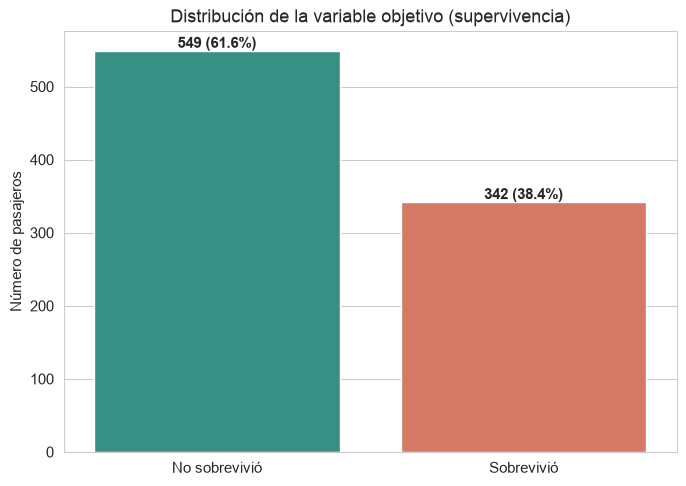

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = df_clean["survived"].map({0: "No sobrevivió", 1: "Sobrevivió"}).value_counts()
sns.barplot(x=counts.index, y=counts.values, palette=[COLOR_NEG, COLOR_POS], ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 4, f"{v} ({100*v/len(df_clean):.1f}%)", ha="center", fontweight="bold")
ax.set_title("Distribución de la variable objetivo (supervivencia)")
ax.set_ylabel("Número de pasajeros"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig(OUT_DIR / "01_distribucion_clases.png", dpi=120); plt.show()

## 8. Estadísticas descriptivas de variables numéricas relevantes

Comparamos `age`, `fare`, `sibsp`, `parch` separadas por clase para ver diferencias.

In [8]:
df_clean.groupby("survived")[["age", "fare", "sibsp", "parch"]].describe().T.round(2)

survived          0       1
age   count  549.00  342.00
      mean    30.03   28.29
      std     12.50   13.76
      min      1.00    0.42
      25%     23.00   21.00
      50%     28.00   28.00
      75%     35.00   35.00
      max     74.00   80.00
fare  count  549.00  342.00
      mean    22.12   48.40
      std     31.39   66.60
      min      0.00    0.00
      25%      7.85   12.48
      50%     10.50   26.00
      75%     26.00   57.00
      max    263.00  512.33
sibsp count  549.00  342.00
      mean     0.55    0.47
      std      1.29    0.71
      min      0.00    0.00
      25%      0.00    0.00
      50%      0.00    0.00
      75%      1.00    1.00
      max      8.00    4.00
parch count  549.00  342.00
      mean     0.33    0.46
      std      0.82    0.77
      min      0.00    0.00
      25%      0.00    0.00
      50%      0.00    0.00
      75%      0.00    1.00
      max      6.00    5.00

## 9. Correlación con el objetivo y selección de características

Calculamos la correlación de Pearson de cada variable con `survived`.

> **Nota metodológica (decisión del equipo):** el notebook de cáncer usó umbral **|r| > 0.4** porque
> el WBCD tiene correlaciones lineales muy fuertes (varias > 0.7). En el **Titanic las correlaciones
> son más débiles** (la mayor, `sex`, ≈ 0.54; `pclass` ≈ −0.34; `fare` ≈ 0.26): con 0.4 solo pasaría
> `sex`, dejando los modelos "mejorados" con una sola variable. Por eso adoptamos **|r| > 0.2**, que
> retiene las 3 variables realmente predictivas (`sex`, `pclass`, `fare`). Esto es coherente con que
> *el Titanic es un problema más difícil y menos separable linealmente* que el WBCD.

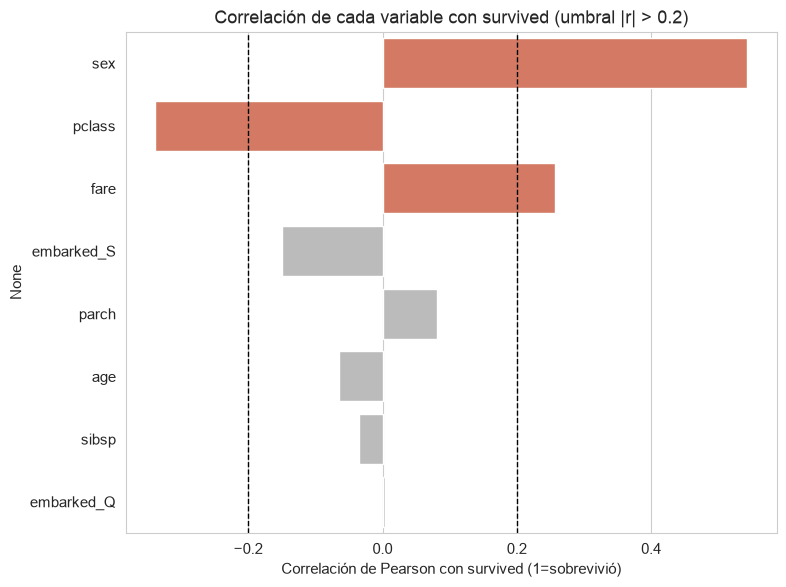

Variables seleccionadas (|r| > 0.2): ['sex', 'pclass', 'fare']
  sex          r = +0.543
  pclass       r = -0.338
  fare         r = +0.257


In [9]:
corr_target = df_clean.corr(numeric_only=True)["survived"].drop("survived").sort_values(key=np.abs, ascending=False)

THRESHOLD = 0.2
selected_features = corr_target[corr_target.abs() > THRESHOLD].index.tolist()

fig, ax = plt.subplots(figsize=(8, 6))
colors = [COLOR_POS if abs(v) > THRESHOLD else "#bbbbbb" for v in corr_target.values]
sns.barplot(x=corr_target.values, y=corr_target.index, palette=colors, ax=ax)
ax.axvline(THRESHOLD, color="k", ls="--", lw=1); ax.axvline(-THRESHOLD, color="k", ls="--", lw=1)
ax.set_title(f"Correlación de cada variable con survived (umbral |r| > {THRESHOLD})")
ax.set_xlabel("Correlación de Pearson con survived (1=sobrevivió)")
plt.tight_layout(); plt.savefig(OUT_DIR / "02_correlacion_target.png", dpi=120); plt.show()

print(f"Variables seleccionadas (|r| > {THRESHOLD}): {selected_features}")
for f in selected_features:
    print(f"  {f:<12} r = {corr_target[f]:+.3f}")

**Interpretación:** `sex` es la variable más predictiva con diferencia (mujeres sobrevivieron mucho
más), seguida de `pclass` (clase social) y `fare` (precio del billete, proxy de la clase). Coincide
con la intuición histórica "mujeres, niños y primera clase primero".

## 10. Histogramas de las variables más predictivas (por clase)

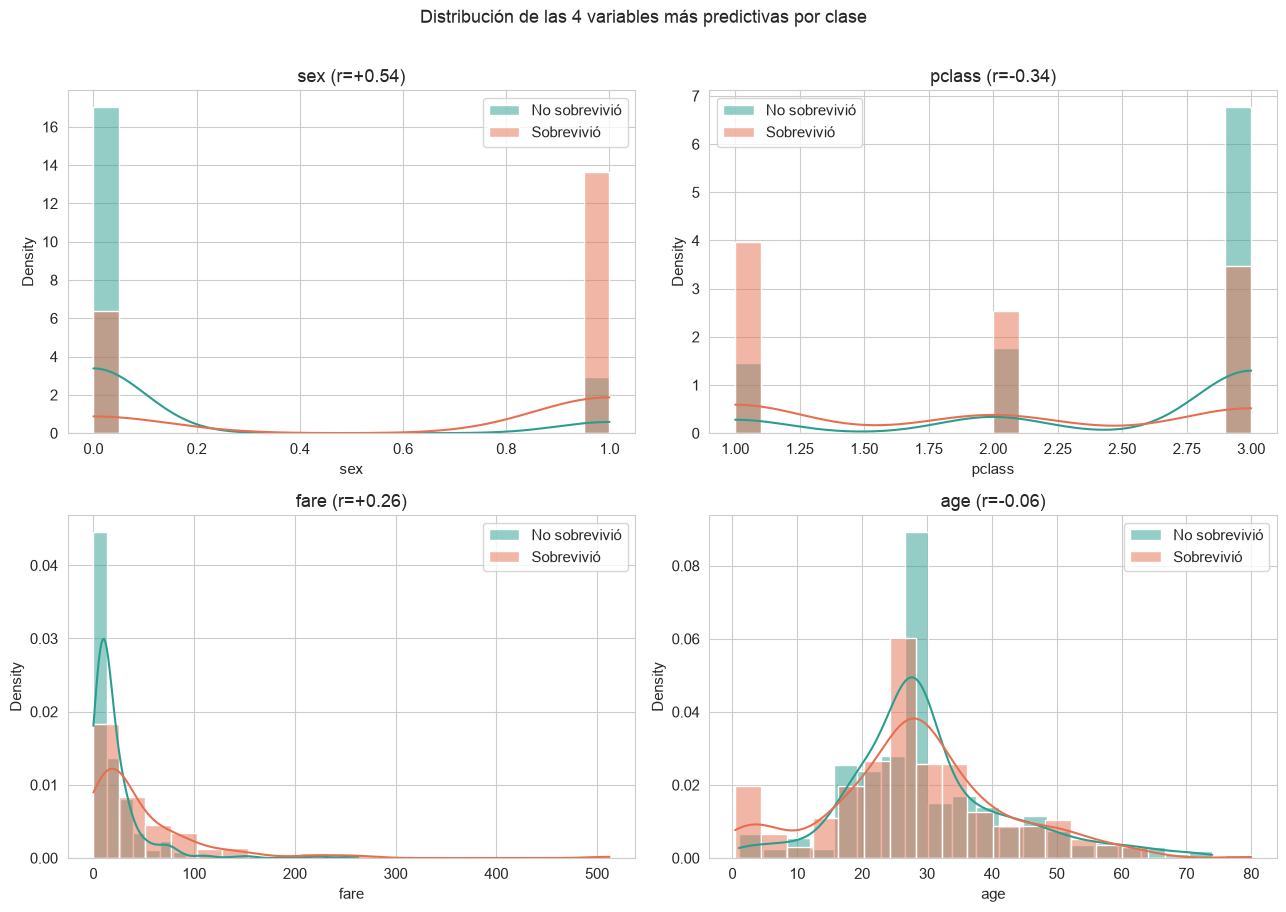

In [10]:
top4 = (selected_features + [c for c in feature_cols if c not in selected_features])[:4]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), top4):
    for cls, color in [(0, COLOR_NEG), (1, COLOR_POS)]:
        sns.histplot(df_clean[df_clean.survived == cls][col], ax=ax, color=color,
                     label={0: "No sobrevivió", 1: "Sobrevivió"}[cls],
                     kde=True, stat="density", alpha=0.5, bins=20)
    ax.set_title(f"{col} (r={corr_target[col]:+.2f})"); ax.legend()
fig.suptitle("Distribución de las 4 variables más predictivas por clase", y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(OUT_DIR / "03_histogramas_top.png", dpi=120); plt.show()

**Interpretación:** las mujeres (`sex=1`) y los pasajeros de 1ª clase (`pclass=1`) muestran clara
mayoría de supervivencia; `fare` alto se asocia a supervivencia (clase alta).

## 11. Boxplots para detección visual de atípicos

¿Los atípicos son ruido o señal? En `fare` son **señal** (billetes de lujo reales); en `age` es más
discutible. Por eso no los eliminamos a ciegas.

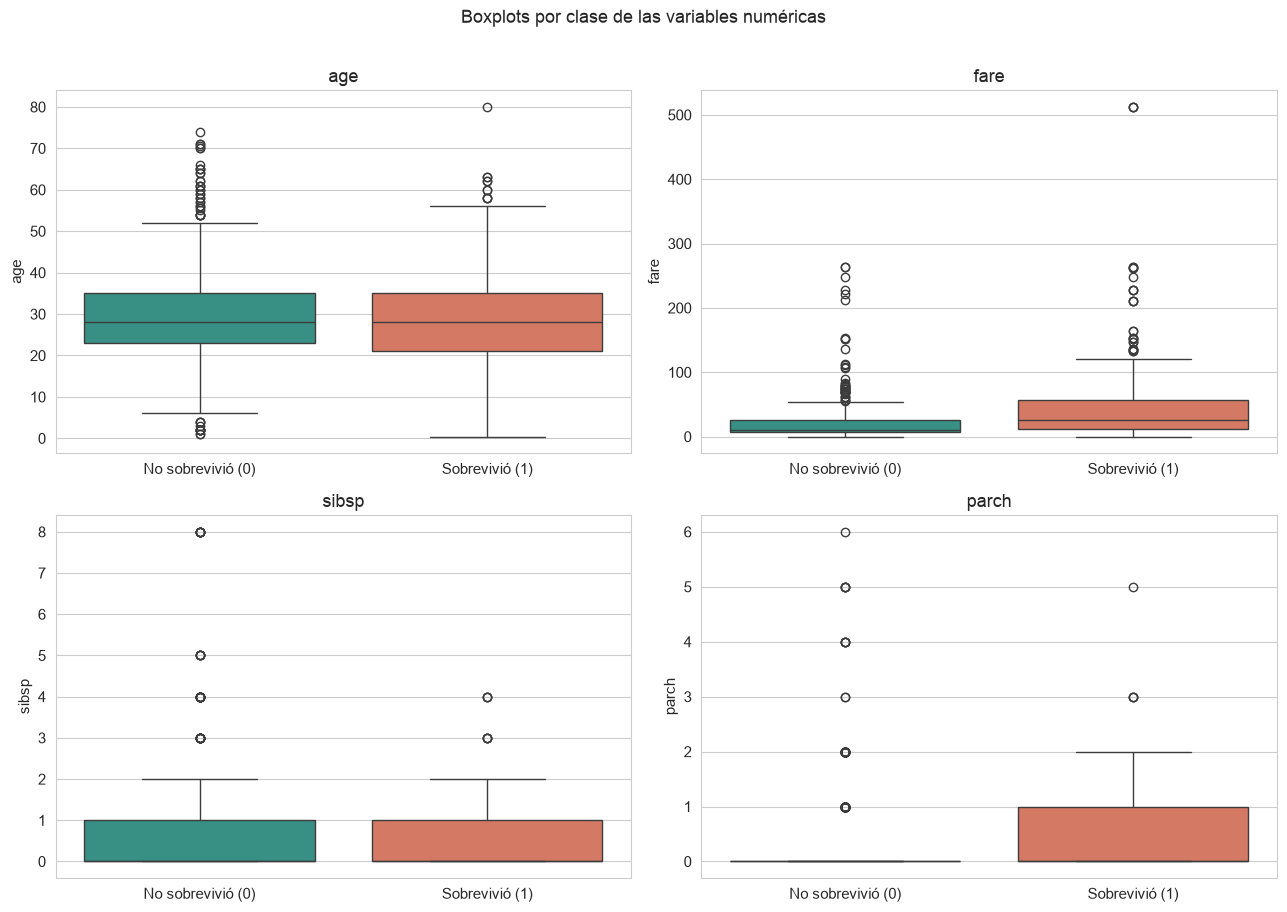

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), ["age", "fare", "sibsp", "parch"]):
    sns.boxplot(data=df_clean, x="survived", y=col, palette=[COLOR_NEG, COLOR_POS], ax=ax)
    ax.set_xticklabels(["No sobrevivió (0)", "Sobrevivió (1)"]); ax.set_xlabel(""); ax.set_title(col)
fig.suptitle("Boxplots por clase de las variables numéricas", y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(OUT_DIR / "04_boxplots.png", dpi=120); plt.show()

## 12. Matriz de correlación entre predictoras (multicolinealidad)

Esperamos correlación negativa entre `pclass` y `fare` (a mayor clase, menor número y mayor precio).

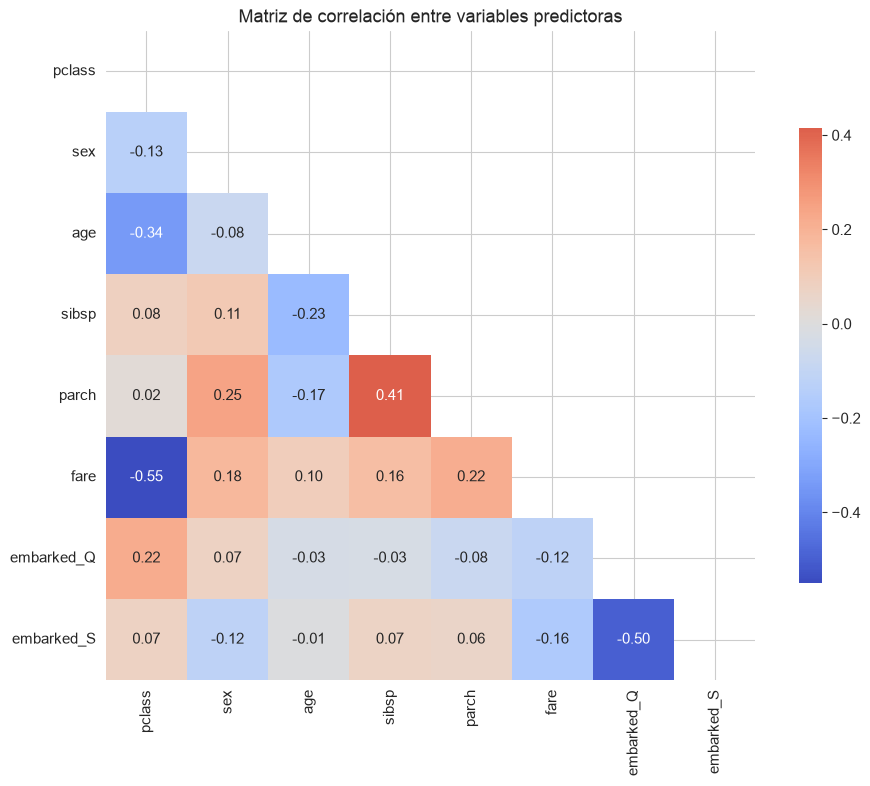

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_clean[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0, square=True,
            annot=True, fmt=".2f", cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Matriz de correlación entre variables predictoras")
plt.tight_layout(); plt.savefig(OUT_DIR / "05_heatmap_correlacion.png", dpi=120); plt.show()

## 13. Conclusiones del EDA

- **Variables más predictivas:** `sex` (la más fuerte), `pclass` y `fare`; el resto aporta poco de
  forma lineal.
- **Decisiones de preprocesamiento:** eliminación de columnas con fuga (`alive`) y redundantes;
  imputación razonada de `age`/`embarked`; codificación de `sex` y `embarked`; atípicos de `fare`
  conservados como señal.
- **Contexto narrativo:** *El Titanic no fue solo una tragedia aleatoria; el análisis muestra que el
  sexo, la clase social y la edad tuvieron un impacto estadísticamente medible en la probabilidad de
  supervivencia.*

---
# Fase III — Modelado y Evaluación

División 80/20 estratificada, `StandardScaler` ajustado **solo con train**, selección de
características (|r|>0.2) para las versiones *mejoradas* y validación cruzada estratificada (5 folds).

## División train/test y escalado

In [13]:
X = df_clean[feature_cols].copy()
y = df_clean["survived"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

std_scaler = StandardScaler().fit(X_train)
mm_scaler = MinMaxScaler().fit(X_train)
X_train_std, X_test_std = std_scaler.transform(X_train), std_scaler.transform(X_test)
X_train_mm,  X_test_mm  = mm_scaler.transform(X_train),  mm_scaler.transform(X_test)

sel_idx = [feature_cols.index(f) for f in selected_features]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"Variables seleccionadas para 'mejorado': {selected_features} (índices {sel_idx})")

Train: 712 | Test: 179
Variables seleccionadas para 'mejorado': ['sex', 'pclass', 'fare'] (índices [1, 0, 5])


## Experimento: StandardScaler vs MinMaxScaler

Misma comparación que Marcelo, con Regresión Logística base. Se adopta el de mejor recall.

In [14]:
scaler_results = []
for name, Xtr, Xte in [("StandardScaler", X_train_std, X_test_std),
                       ("MinMaxScaler",  X_train_mm,  X_test_mm)]:
    clf = LogisticRegression(max_iter=5000, random_state=SEED).fit(Xtr, y_train)
    pred = clf.predict(Xte)
    scaler_results.append({"Escalador": name,
                           "Accuracy": accuracy_score(y_test, pred),
                           "Recall": recall_score(y_test, pred),
                           "F1": f1_score(y_test, pred)})
print(pd.DataFrame(scaler_results).round(4).to_string(index=False))
print("\nDecisión: se adopta StandardScaler (apropiado para KNN/SVM/lineales y redes neuronales).")

     Escalador  Accuracy  Recall     F1
StandardScaler    0.8045  0.6667 0.7244
  MinMaxScaler    0.7933  0.6667 0.7132

Decisión: se adopta StandardScaler (apropiado para KNN/SVM/lineales y redes neuronales).


## Experimento: con vs sin outliers en el entrenamiento

La máscara IQR se calcula **solo sobre el train** (nunca tocamos el test).

In [15]:
train_mask, _ = iqr_outlier_mask(X_train.assign(survived=y_train), ["age", "fare", "sibsp", "parch"])
keep = ~train_mask.values
exp = []
for label, Xtr, ytr in [("Conservar atípicos", X_train_std, y_train),
                        ("Eliminar atípicos",  X_train_std[keep], y_train[keep])]:
    clf = LogisticRegression(max_iter=5000, random_state=SEED).fit(Xtr, ytr)
    pred = clf.predict(X_test_std)
    exp.append({"Estrategia": label, "n_train": len(ytr),
                "Accuracy": accuracy_score(y_test, pred), "Recall": recall_score(y_test, pred),
                "F1": f1_score(y_test, pred)})
print(pd.DataFrame(exp).round(4).to_string(index=False))
print("\nDecisión: se CONSERVAN los atípicos (los de fare son señal real de clase alta; eliminarlos "
      "reduce la muestra sin mejorar el recall de forma consistente).")

        Estrategia  n_train  Accuracy  Recall     F1
Conservar atípicos      712    0.8045  0.6667 0.7244
 Eliminar atípicos      466    0.7709  0.7246 0.7092

Decisión: se CONSERVAN los atípicos (los de fare son señal real de clase alta; eliminarlos reduce la muestra sin mejorar el recall de forma consistente).


## Funciones de evaluación reutilizables

**Idénticas a las del notebook de Marcelo** (la de `evaluate` es compatible con sklearn y Keras),
solo se adaptan las etiquetas de la matriz de confusión al contexto del Titanic.

In [16]:
results = []                 # se llena con cada modelo/versión
best_models = {}
model_sizes = {}             # tamaño (MB) de cada modelo guardado

def evaluate(model, Xte, yte, name, version, save_key=None):
    # Misma implementación que Marcelo: compatible con sklearn y Keras
    if isinstance(model, tf.keras.Model):
        proba = model.predict(Xte, verbose=0).ravel()
        pred = (proba > 0.5).astype(int)
    else:
        pred = model.predict(Xte)
        proba = model.predict_proba(Xte)[:, 1]
    row = {"Modelo": name, "Versión": version,
           "Accuracy": accuracy_score(yte, pred), "Precision": precision_score(yte, pred),
           "Recall": recall_score(yte, pred), "F1": f1_score(yte, pred),
           "AUC": roc_auc_score(yte, proba)}
    results.append(row)
    return row, pred, proba

def plot_confusion(yte, pred, title, save_key=None):
    cm = confusion_matrix(yte, pred); tn, fp, fn, tp = cm.ravel()
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    labels = np.array([[f"TN\n{tn}", f"FP\n{fp}"], [f"FN\n{fn}", f"TP\n{tp}"]])
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=["No Sobrevivió (0)", "Sobrevivió (1)"],
                yticklabels=["No Sobrevivió (0)", "Sobrevivió (1)"], ax=ax)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real"); ax.set_title(title)
    plt.tight_layout()
    if save_key: plt.savefig(OUT_DIR / save_key, dpi=120)
    plt.show()
    return tn, fp, fn, tp

def plot_roc(curves, title, save_key=None):
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    for label, yte, proba in curves:
        fpr, tpr, _ = roc_curve(yte, proba)
        ax.plot(fpr, tpr, lw=2, label=f"{label} (AUC={roc_auc_score(yte, proba):.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Azar")
    ax.set_xlabel("Tasa de Falsos Positivos"); ax.set_ylabel("Tasa de Verdaderos Positivos (Recall)")
    ax.set_title(title); ax.legend(loc="lower right")
    plt.tight_layout()
    if save_key: plt.savefig(OUT_DIR / save_key, dpi=120)
    plt.show()

def save_sklearn(model, name, fname):
    joblib.dump(model, MODELS_DIR / fname)
    model_sizes[name] = os.path.getsize(MODELS_DIR / fname) / (1024 * 1024)
    best_models[name] = model
    print(f"Guardado: models/{fname} ({model_sizes[name]:.4f} MB)")

## 15. Modelo 1 — Regresión Logística

**Baseline:** `LogisticRegression(max_iter=5000)` con todas las variables. **Mejorada:** `GridSearchCV` (solver, max_iter, C), `scoring='recall'`, con variables seleccionadas. Es interpretable: permite explicar qué variables impulsaron la predicción de supervivencia.

BASELINE: {'Accuracy': 0.8045, 'Precision': 0.7931, 'Recall': 0.6667, 'F1': 0.7244, 'AUC': 0.8433}


Mejores hiperparámetros: {'C': 0.1, 'max_iter': 100, 'solver': 'lbfgs'}
MEJORADO: {'Accuracy': 0.7765, 'Precision': 0.7302, 'Recall': 0.6667, 'F1': 0.697, 'AUC': 0.82}


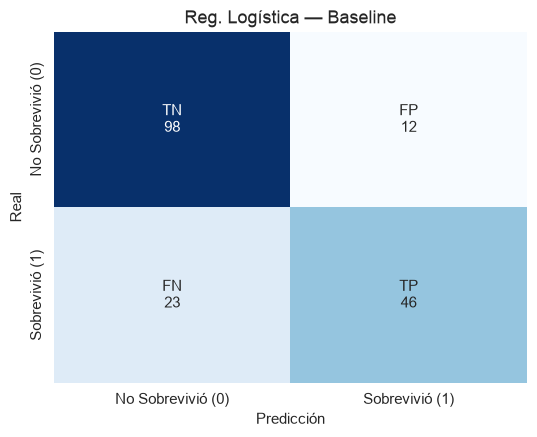

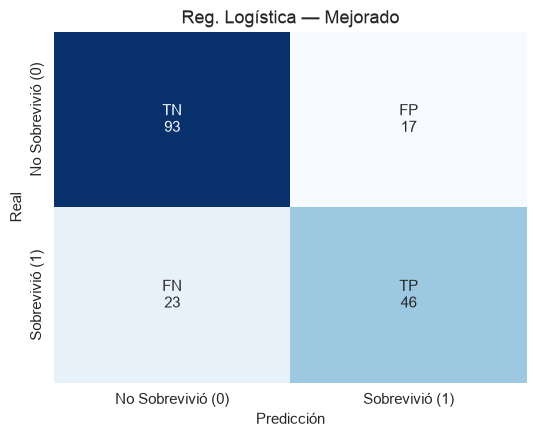

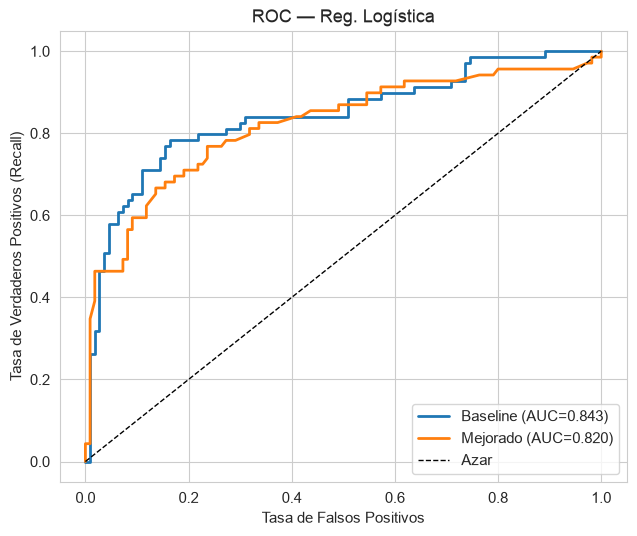

Guardado: models/best_logistic_regression_model.joblib (0.0009 MB)


In [17]:
logreg_base = LogisticRegression(max_iter=5000, random_state=SEED).fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(logreg_base, X_test_std, y_test, "Reg. Logística", "Baseline")
print("BASELINE:", {k: round(v,4) for k,v in row_b.items() if isinstance(v,float)})

param_grid_lr = {"solver": ["lbfgs", "saga", "newton-cg"], "max_iter": [100, 300, 500], "C": [0.1, 1, 10]}
grid_lr = GridSearchCV(LogisticRegression(random_state=SEED), param_grid_lr, scoring="recall", cv=cv, n_jobs=-1)
grid_lr.fit(X_train_std[:, sel_idx], y_train)
logreg_best = grid_lr.best_estimator_
row_m, pred_m, proba_m = evaluate(logreg_best, X_test_std[:, sel_idx], y_test, "Reg. Logística", "Mejorado")
print("Mejores hiperparámetros:", grid_lr.best_params_)
print("MEJORADO:", {k: round(v,4) for k,v in row_m.items() if isinstance(v,float)})

plot_confusion(y_test, pred_b, "Reg. Logística — Baseline", "m1_lr_cm_base.png")
plot_confusion(y_test, pred_m, "Reg. Logística — Mejorado", "m1_lr_cm_mej.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)], "ROC — Reg. Logística", "m1_lr_roc.png")
save_sklearn(logreg_best, "Reg. Logística", "best_logistic_regression_model.joblib")

### Importancia de características (coeficientes) — análisis adicional

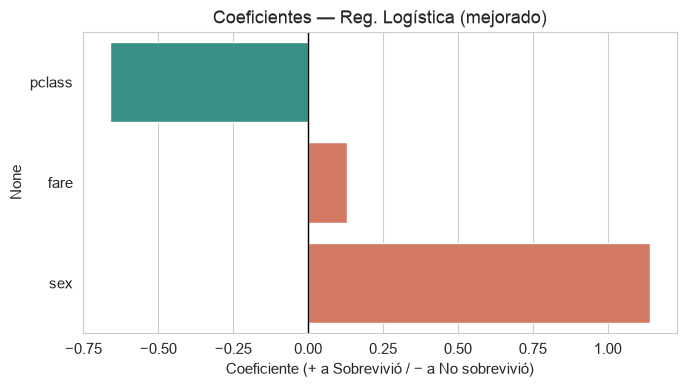

In [18]:
coefs = pd.Series(logreg_best.coef_[0], index=selected_features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=coefs.values, y=coefs.index,
            palette=[COLOR_NEG if c < 0 else COLOR_POS for c in coefs.values], ax=ax)
ax.axvline(0, color="k", lw=1); ax.set_title("Coeficientes — Reg. Logística (mejorado)")
ax.set_xlabel("Coeficiente (+ a Sobrevivió / − a No sobrevivió)")
plt.tight_layout(); plt.savefig(OUT_DIR / "m1_lr_coef.png", dpi=120); plt.show()

**Comparación:** la versión mejorada usa solo `sex/pclass/fare`. `sex` tiene el coeficiente positivo más alto (ser mujer aumenta la probabilidad de sobrevivir), `pclass` negativo (clases más altas = número menor = mayor supervivencia).

## 16. Modelo 2 — K-Nearest Neighbors (KNN)

KNN es sensible a la escala — **siempre normalizar antes**. **Baseline:** `KNeighborsClassifier()`. **Mejorada:** `GridSearchCV` (n_neighbors, metric, weights).

BASELINE: {'Accuracy': 0.8156, 'Precision': 0.8, 'Recall': 0.6957, 'F1': 0.7442, 'AUC': 0.845}


Mejores hiperparámetros: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
MEJORADO: {'Accuracy': 0.7765, 'Precision': 0.7302, 'Recall': 0.6667, 'F1': 0.697, 'AUC': 0.7989}


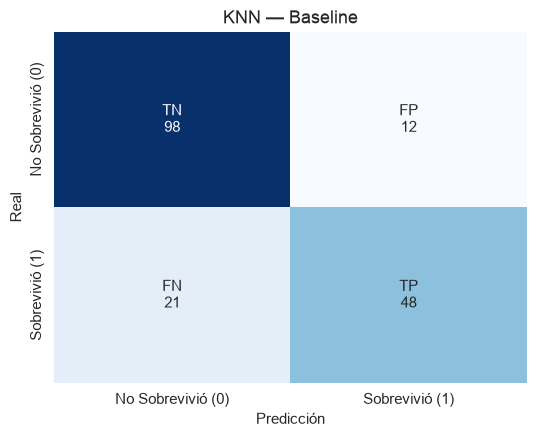

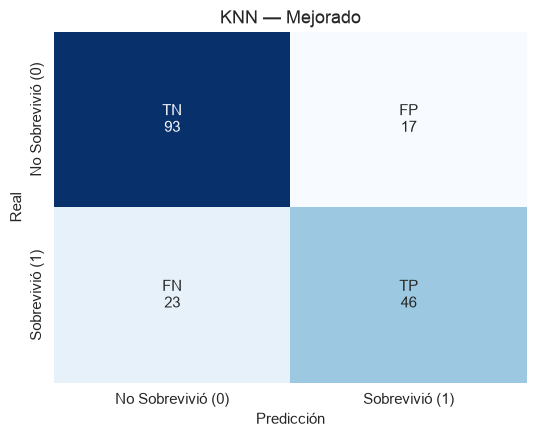

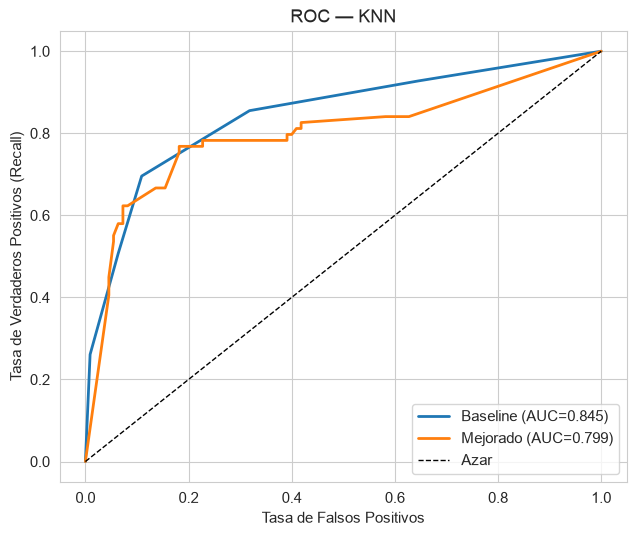

Guardado: models/best_knn_model.joblib (0.0472 MB)


In [19]:
knn_base = KNeighborsClassifier().fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(knn_base, X_test_std, y_test, "KNN", "Baseline")
print("BASELINE:", {k: round(v,4) for k,v in row_b.items() if isinstance(v,float)})

param_grid_knn = {"n_neighbors": [3,5,7,9,11], "metric": ["euclidean","manhattan"], "weights": ["uniform","distance"]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring="recall", cv=cv, n_jobs=-1)
grid_knn.fit(X_train_std[:, sel_idx], y_train)
knn_best = grid_knn.best_estimator_
row_m, pred_m, proba_m = evaluate(knn_best, X_test_std[:, sel_idx], y_test, "KNN", "Mejorado")
print("Mejores hiperparámetros:", grid_knn.best_params_)
print("MEJORADO:", {k: round(v,4) for k,v in row_m.items() if isinstance(v,float)})

plot_confusion(y_test, pred_b, "KNN — Baseline", "m2_knn_cm_base.png")
plot_confusion(y_test, pred_m, "KNN — Mejorado", "m2_knn_cm_mej.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)], "ROC — KNN", "m2_knn_roc.png")
save_sklearn(knn_best, "KNN", "best_knn_model.joblib")

## 17. Modelo 3 — Naive Bayes Gaussiano

El Titanic tiene variables correlacionadas (`pclass`/`fare`) que **violan el supuesto de independencia** de Naive Bayes — esperamos un recall bajo. **Mejorada:** `GridSearchCV` sobre `var_smoothing`.

BASELINE: {'Accuracy': 0.7821, 'Precision': 0.7273, 'Recall': 0.6957, 'F1': 0.7111, 'AUC': 0.8075}
Mejores hiperparámetros: {'var_smoothing': 1e-09}
MEJORADO: {'Accuracy': 0.7598, 'Precision': 0.6806, 'Recall': 0.7101, 'F1': 0.695, 'AUC': 0.8005}


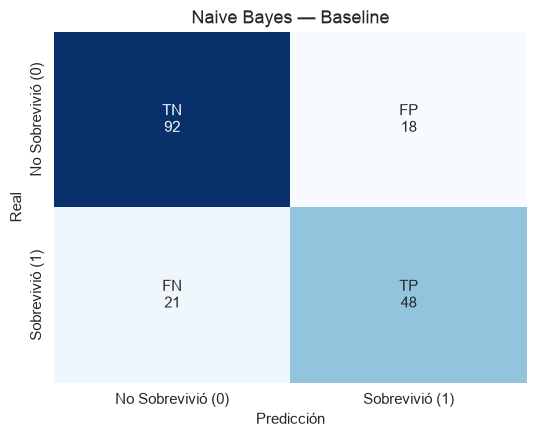

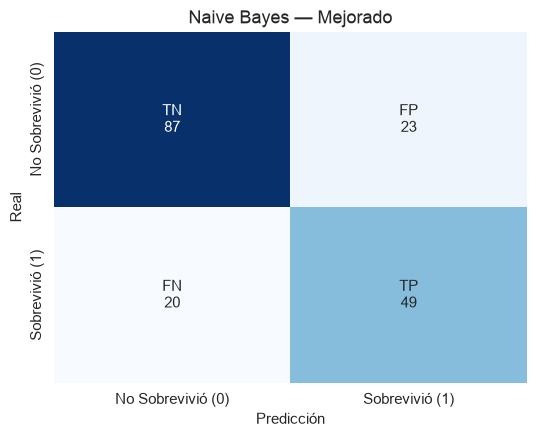

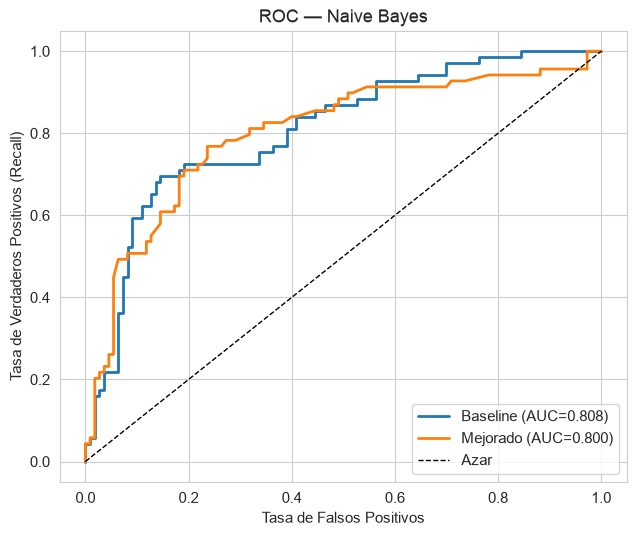

Guardado: models/best_naive_bayes_model.joblib (0.0008 MB)


In [20]:
nb_base = GaussianNB().fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(nb_base, X_test_std, y_test, "Naive Bayes", "Baseline")
print("BASELINE:", {k: round(v,4) for k,v in row_b.items() if isinstance(v,float)})

grid_nb = GridSearchCV(GaussianNB(), {"var_smoothing": [1e-9,1e-8,1e-7,1e-6]}, scoring="recall", cv=cv, n_jobs=-1)
grid_nb.fit(X_train_std[:, sel_idx], y_train)
nb_best = grid_nb.best_estimator_
row_m, pred_m, proba_m = evaluate(nb_best, X_test_std[:, sel_idx], y_test, "Naive Bayes", "Mejorado")
print("Mejores hiperparámetros:", grid_nb.best_params_)
print("MEJORADO:", {k: round(v,4) for k,v in row_m.items() if isinstance(v,float)})

plot_confusion(y_test, pred_b, "Naive Bayes — Baseline", "m3_nb_cm_base.png")
plot_confusion(y_test, pred_m, "Naive Bayes — Mejorado", "m3_nb_cm_mej.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)], "ROC — Naive Bayes", "m3_nb_roc.png")
save_sklearn(nb_best, "Naive Bayes", "best_naive_bayes_model.joblib")

## 18. Modelo 4 — Random Forest (propuesta del equipo)

Ensamble de árboles (*bagging*). **Mejorada:** `GridSearchCV` (n_estimators, max_depth, min_samples_split, max_features). Aporta su propia importancia por Gini.

BASELINE: {'Accuracy': 0.8101, 'Precision': 0.7869, 'Recall': 0.6957, 'F1': 0.7385, 'AUC': 0.8333}


Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
MEJORADO: {'Accuracy': 0.7709, 'Precision': 0.7, 'Recall': 0.7101, 'F1': 0.705, 'AUC': 0.8232}


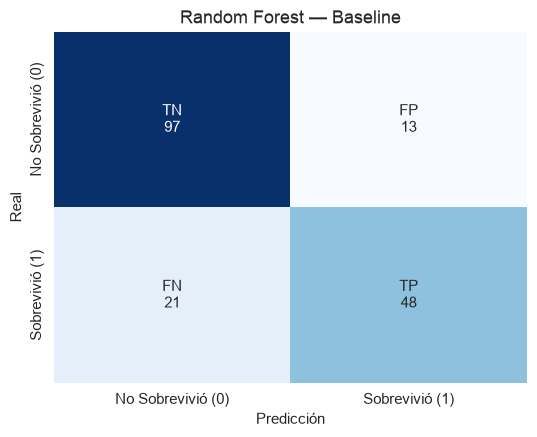

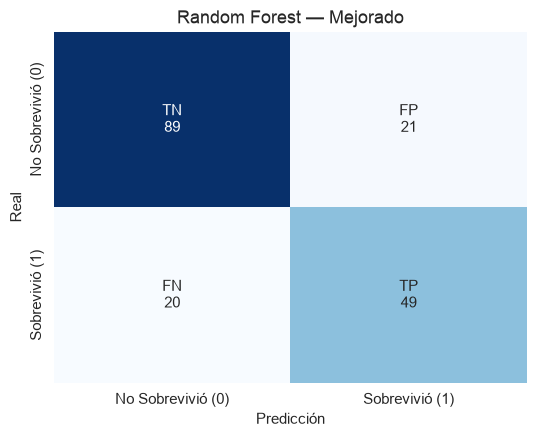

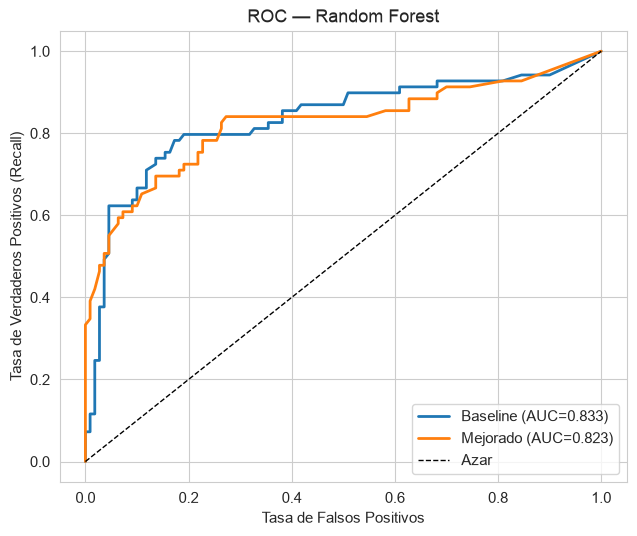

Guardado: models/best_random_forest_model.joblib (1.5905 MB)


In [21]:
rf_base = RandomForestClassifier(random_state=SEED).fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(rf_base, X_test_std, y_test, "Random Forest", "Baseline")
print("BASELINE:", {k: round(v,4) for k,v in row_b.items() if isinstance(v,float)})

param_grid_rf = {"n_estimators":[100,200,300], "max_depth":[None,5,10], "min_samples_split":[2,5], "max_features":["sqrt","log2"]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=SEED), param_grid_rf, scoring="recall", cv=cv, n_jobs=-1)
grid_rf.fit(X_train_std[:, sel_idx], y_train)
rf_best = grid_rf.best_estimator_
row_m, pred_m, proba_m = evaluate(rf_best, X_test_std[:, sel_idx], y_test, "Random Forest", "Mejorado")
print("Mejores hiperparámetros:", grid_rf.best_params_)
print("MEJORADO:", {k: round(v,4) for k,v in row_m.items() if isinstance(v,float)})

plot_confusion(y_test, pred_b, "Random Forest — Baseline", "m4_rf_cm_base.png")
plot_confusion(y_test, pred_m, "Random Forest — Mejorado", "m4_rf_cm_mej.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)], "ROC — Random Forest", "m4_rf_roc.png")
save_sklearn(rf_best, "Random Forest", "best_random_forest_model.joblib")

### Importancia de características (Random Forest, Gini) — análisis adicional

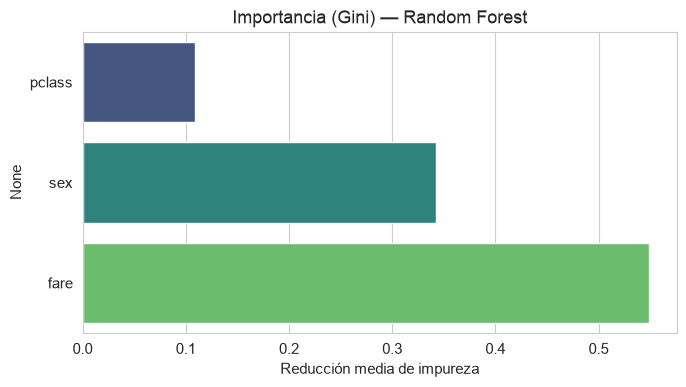

In [22]:
rf_imp = pd.Series(rf_best.feature_importances_, index=selected_features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=rf_imp.values, y=rf_imp.index, palette="viridis", ax=ax)
ax.set_title("Importancia (Gini) — Random Forest"); ax.set_xlabel("Reducción media de impureza")
plt.tight_layout(); plt.savefig(OUT_DIR / "m4_rf_gini.png", dpi=120); plt.show()

**Contraste con la Regresión Logística:** ambos coinciden en que `sex` es la variable más importante, lo que refuerza la validez del hallazgo desde dos enfoques distintos (lineal y de árboles).

## 19. Modelo 5 — Árbol de Decisión

**Mejorada:** `RandomizedSearchCV` (max_depth, min_samples_leaf, criterion).

BASELINE: {'Accuracy': 0.8212, 'Precision': 0.7846, 'Recall': 0.7391, 'F1': 0.7612, 'AUC': 0.8039}


Mejores hiperparámetros: {'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'gini'}
MEJORADO: {'Accuracy': 0.7709, 'Precision': 0.7188, 'Recall': 0.6667, 'F1': 0.6917, 'AUC': 0.7676}


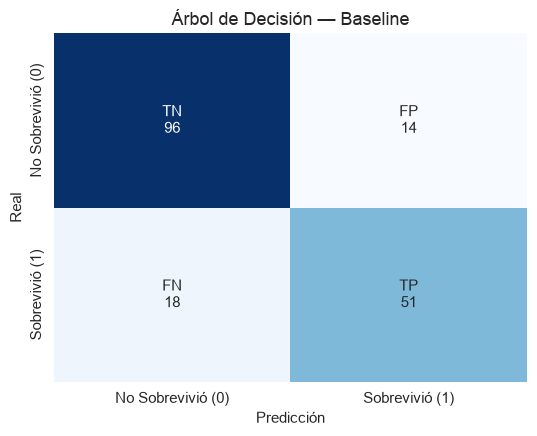

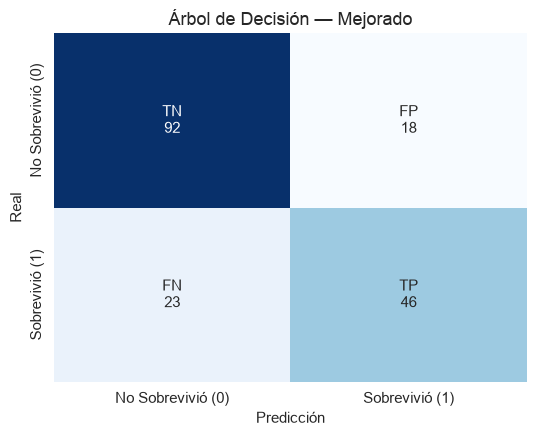

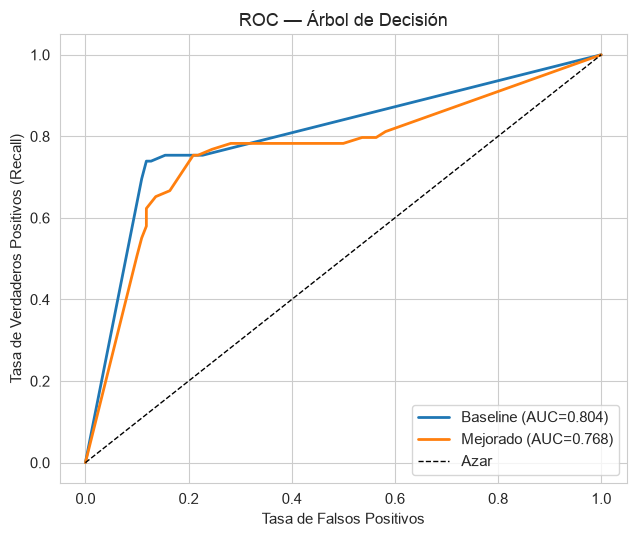

Guardado: models/best_dtree_model.joblib (0.0216 MB)


In [23]:
dt_base = DecisionTreeClassifier(random_state=SEED).fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(dt_base, X_test_std, y_test, "Árbol de Decisión", "Baseline")
print("BASELINE:", {k: round(v,4) for k,v in row_b.items() if isinstance(v,float)})

param_dist_dt = {"max_depth":[3,5,7,10,None], "min_samples_leaf":[1,2,5,10], "criterion":["gini","entropy"]}
rs_dt = RandomizedSearchCV(DecisionTreeClassifier(random_state=SEED), param_dist_dt,
                           n_iter=20, scoring="recall", cv=cv, n_jobs=-1, random_state=SEED)
rs_dt.fit(X_train_std[:, sel_idx], y_train)
dt_best = rs_dt.best_estimator_
row_m, pred_m, proba_m = evaluate(dt_best, X_test_std[:, sel_idx], y_test, "Árbol de Decisión", "Mejorado")
print("Mejores hiperparámetros:", rs_dt.best_params_)
print("MEJORADO:", {k: round(v,4) for k,v in row_m.items() if isinstance(v,float)})

plot_confusion(y_test, pred_b, "Árbol de Decisión — Baseline", "m5_dt_cm_base.png")
plot_confusion(y_test, pred_m, "Árbol de Decisión — Mejorado", "m5_dt_cm_mej.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)], "ROC — Árbol de Decisión", "m5_dt_roc.png")
save_sklearn(dt_best, "Árbol de Decisión", "best_dtree_model.joblib")

## 20. Modelo 6 — Máquinas de Vectores de Soporte (SVM)

**Baseline:** `SVC(probability=True)`. **Mejorada:** `RandomizedSearchCV` (C, kernel, gamma), n_iter=20.

BASELINE: {'Accuracy': 0.8101, 'Precision': 0.8431, 'Recall': 0.6232, 'F1': 0.7167, 'AUC': 0.8374}


Mejores hiperparámetros: {'kernel': 'rbf', 'gamma': 'scale', 'C': 0.1}
MEJORADO: {'Accuracy': 0.7821, 'Precision': 0.7419, 'Recall': 0.6667, 'F1': 0.7023, 'AUC': 0.8055}


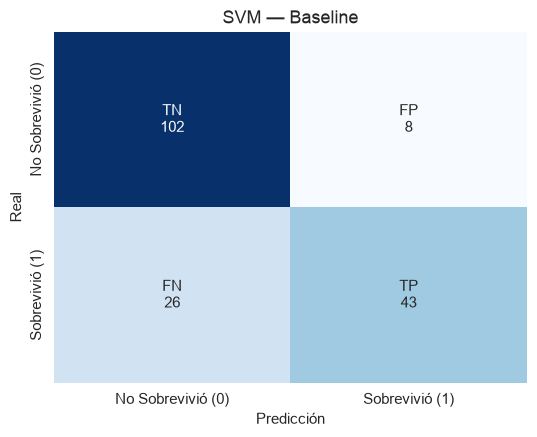

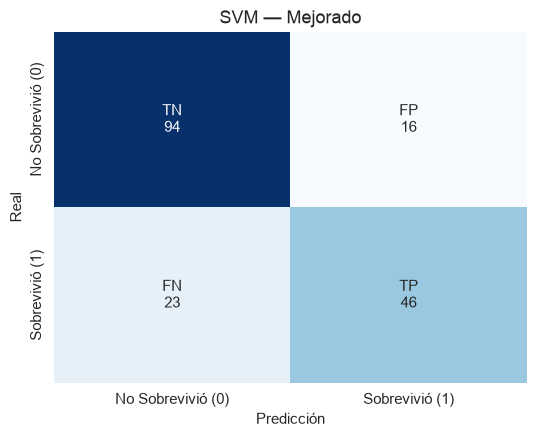

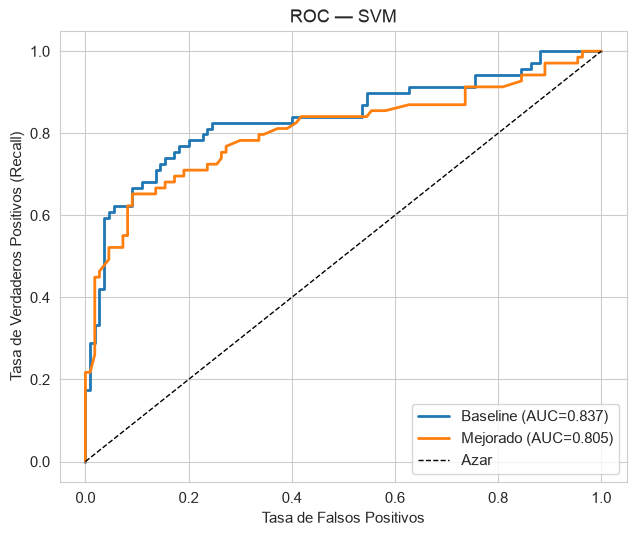

Guardado: models/best_svm_model.joblib (0.0170 MB)


In [24]:
svm_base = SVC(random_state=SEED, probability=True).fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(svm_base, X_test_std, y_test, "SVM", "Baseline")
print("BASELINE:", {k: round(v,4) for k,v in row_b.items() if isinstance(v,float)})

param_dist_svm = {"C":[0.1,1,10,100], "kernel":["linear","rbf","poly"], "gamma":["scale","auto"]}
rs_svm = RandomizedSearchCV(SVC(random_state=SEED, probability=True), param_dist_svm,
                            n_iter=20, scoring="recall", cv=cv, n_jobs=-1, random_state=SEED)
rs_svm.fit(X_train_std[:, sel_idx], y_train)
svm_best = rs_svm.best_estimator_
row_m, pred_m, proba_m = evaluate(svm_best, X_test_std[:, sel_idx], y_test, "SVM", "Mejorado")
print("Mejores hiperparámetros:", rs_svm.best_params_)
print("MEJORADO:", {k: round(v,4) for k,v in row_m.items() if isinstance(v,float)})

plot_confusion(y_test, pred_b, "SVM — Baseline", "m6_svm_cm_base.png")
plot_confusion(y_test, pred_m, "SVM — Mejorado", "m6_svm_cm_mej.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)], "ROC — SVM", "m6_svm_roc.png")
save_sklearn(svm_best, "SVM", "best_svm_model.joblib")

## 21. Modelo 7 — Gradient Boosting

Ensamble secuencial (*boosting*). **Mejorada:** `RandomizedSearchCV` (n_estimators, learning_rate, max_depth, subsample), n_iter=20.

BASELINE: {'Accuracy': 0.7989, 'Precision': 0.7895, 'Recall': 0.6522, 'F1': 0.7143, 'AUC': 0.8179}


Mejores hiperparámetros: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
MEJORADO: {'Accuracy': 0.7821, 'Precision': 0.7273, 'Recall': 0.6957, 'F1': 0.7111, 'AUC': 0.8356}


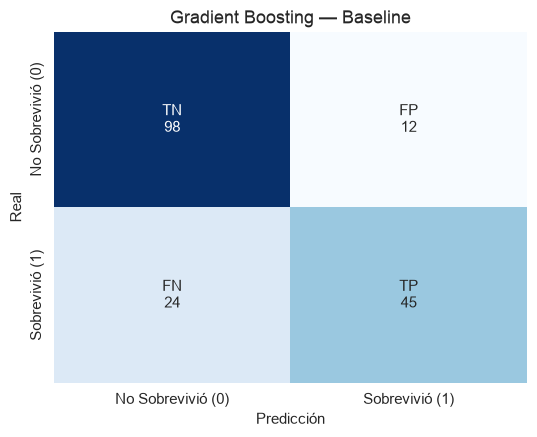

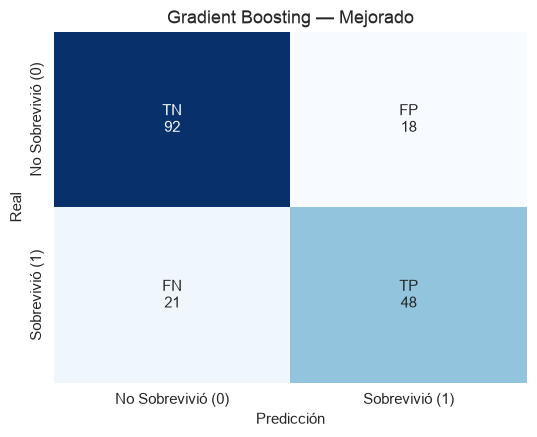

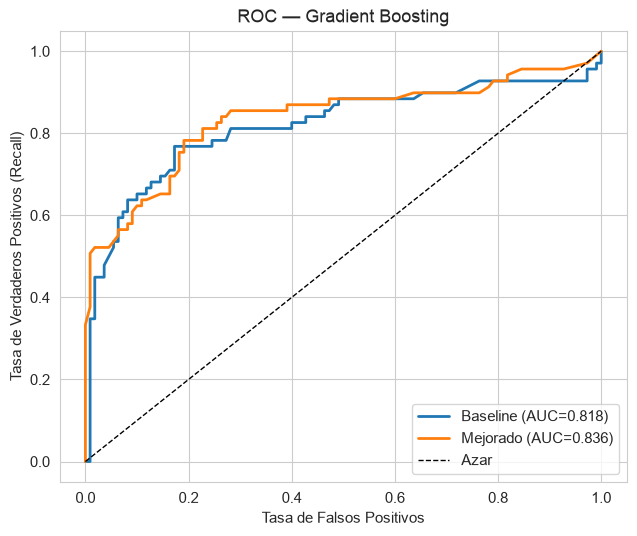

Guardado: models/best_gbm_model.joblib (0.2499 MB)


In [25]:
gbm_base = GradientBoostingClassifier(random_state=SEED).fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(gbm_base, X_test_std, y_test, "Gradient Boosting", "Baseline")
print("BASELINE:", {k: round(v,4) for k,v in row_b.items() if isinstance(v,float)})

param_dist_gbm = {"n_estimators":[50,100,200], "learning_rate":[0.01,0.05,0.1], "max_depth":[3,5,7], "subsample":[0.7,0.8,1.0]}
rs_gbm = RandomizedSearchCV(GradientBoostingClassifier(random_state=SEED), param_dist_gbm,
                            n_iter=20, scoring="recall", cv=cv, n_jobs=-1, random_state=SEED)
rs_gbm.fit(X_train_std[:, sel_idx], y_train)
gbm_best = rs_gbm.best_estimator_
row_m, pred_m, proba_m = evaluate(gbm_best, X_test_std[:, sel_idx], y_test, "Gradient Boosting", "Mejorado")
print("Mejores hiperparámetros:", rs_gbm.best_params_)
print("MEJORADO:", {k: round(v,4) for k,v in row_m.items() if isinstance(v,float)})

plot_confusion(y_test, pred_b, "Gradient Boosting — Baseline", "m7_gbm_cm_base.png")
plot_confusion(y_test, pred_m, "Gradient Boosting — Mejorado", "m7_gbm_cm_mej.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)], "ROC — Gradient Boosting", "m7_gbm_roc.png")
save_sklearn(gbm_best, "Gradient Boosting", "best_gbm_model.joblib")

## 22. Modelo 8 — Red Neuronal (TensorFlow/Keras)

Usamos `class_weight` balanceado para manejar el desbalance y favorecer el **recall**. `EarlyStopping`
(patience=10, `restore_best_weights`) evita el sobreajuste. La función `evaluate()` ya está preparada
para modelos Keras (umbral 0.5 sobre la probabilidad sigmoide).

**Arquitectura Baseline:** Dense(16, relu) → Dropout(0.2) → Dense(1, sigmoid).

In [26]:
cw = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight = dict(enumerate(cw))
print("Pesos de clase:", {k: round(v, 3) for k, v in class_weight.items()})

def build_nn(hidden):
    m = keras.Sequential([layers.Input(shape=(X_train_std.shape[1],))])
    for units, drop in hidden:
        m.add(layers.Dense(units, activation="relu")); m.add(layers.Dropout(drop))
    m.add(layers.Dense(1, activation="sigmoid"))
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

# --- Baseline ---
nn_base = build_nn([(16, 0.2)])
hist_b = nn_base.fit(X_train_std, y_train, epochs=100, batch_size=16, validation_split=0.2,
                     class_weight=class_weight, callbacks=[es], verbose=0)
row_b, pred_b, proba_b = evaluate(nn_base, X_test_std, y_test, "Red Neuronal", "Baseline")
print("BASELINE:", {k: round(v,4) for k,v in row_b.items() if isinstance(v,float)})
print(f"Épocas entrenadas (early stopping): {len(hist_b.history['loss'])}")
nn_base.save(MODELS_DIR / "best_neural_network_model_baseline.keras")
model_sizes["Red Neuronal_Baseline"] = os.path.getsize(MODELS_DIR / "best_neural_network_model_baseline.keras") / (1024*1024)

Pesos de clase: {0: 0.811, 1: 1.304}


BASELINE: {'Accuracy': 0.7821, 'Precision': 0.7143, 'Recall': 0.7246, 'F1': 0.7194, 'AUC': 0.8553}
Épocas entrenadas (early stopping): 43


**Arquitectura Mejorada:** Dense(32, relu) → Dropout(0.3) → Dense(16, relu) → Dropout(0.2) → Dense(1).

MEJORADO: {'Accuracy': 0.7877, 'Precision': 0.7246, 'Recall': 0.7246, 'F1': 0.7246, 'AUC': 0.8593}
Épocas entrenadas (early stopping): 28


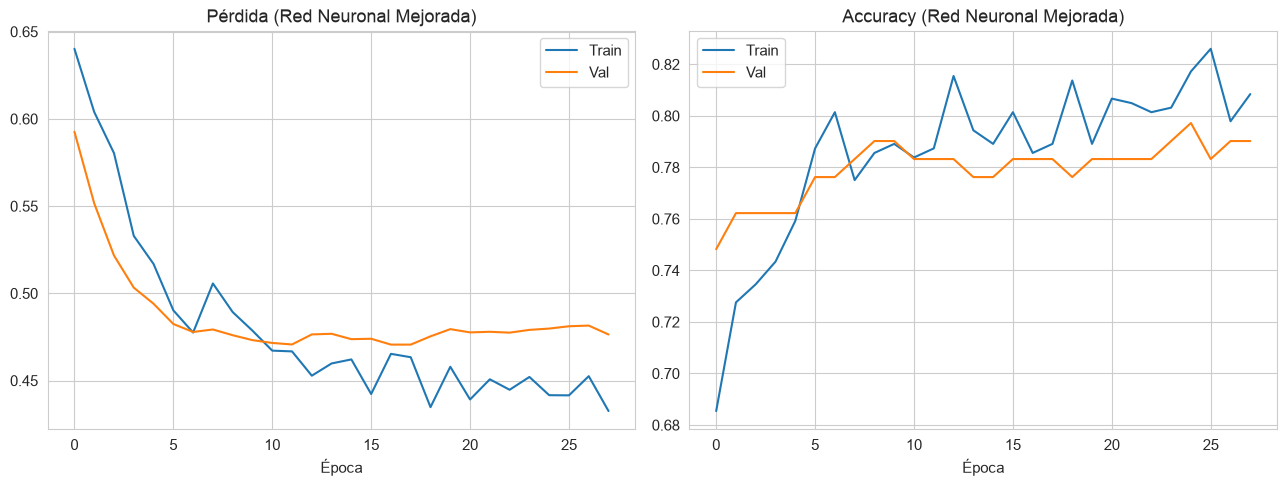

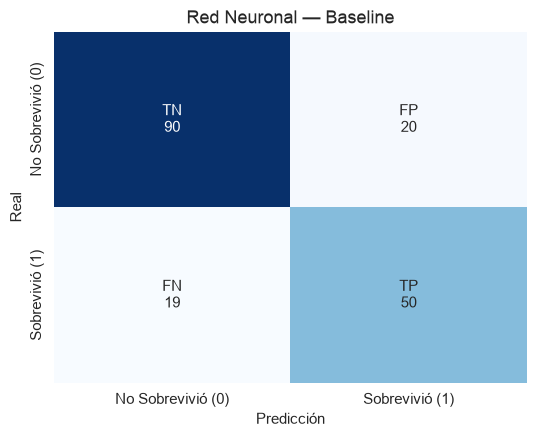

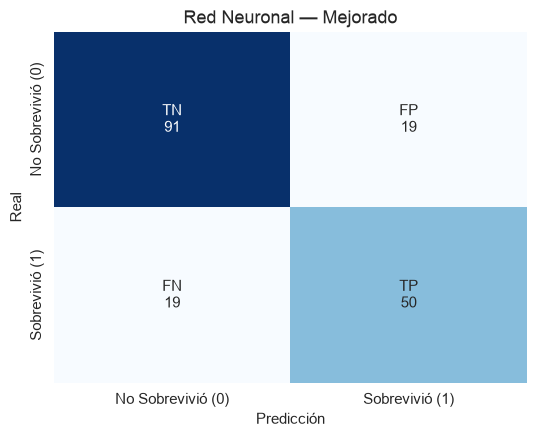

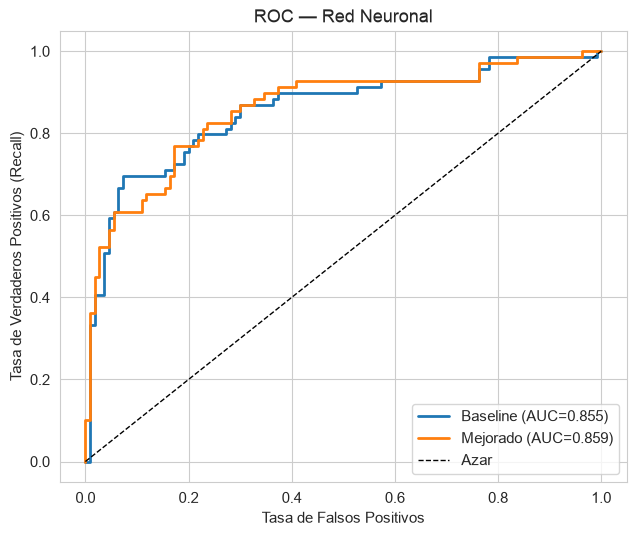

In [27]:
nn_mej = build_nn([(32, 0.3), (16, 0.2)])
es2 = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
hist_m = nn_mej.fit(X_train_std, y_train, epochs=100, batch_size=16, validation_split=0.2,
                    class_weight=class_weight, callbacks=[es2], verbose=0)
row_m, pred_m, proba_m = evaluate(nn_mej, X_test_std, y_test, "Red Neuronal", "Mejorado")
print("MEJORADO:", {k: round(v,4) for k,v in row_m.items() if isinstance(v,float)})
print(f"Épocas entrenadas (early stopping): {len(hist_m.history['loss'])}")
nn_mej.save(MODELS_DIR / "best_neural_network_model_mejorado.keras")
model_sizes["Red Neuronal_Mejorado"] = os.path.getsize(MODELS_DIR / "best_neural_network_model_mejorado.keras") / (1024*1024)
best_models["Red Neuronal"] = nn_mej

# Curvas de aprendizaje (mejorada)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(hist_m.history["loss"], label="Train"); axes[0].plot(hist_m.history["val_loss"], label="Val")
axes[0].set_title("Pérdida (Red Neuronal Mejorada)"); axes[0].set_xlabel("Época"); axes[0].legend()
axes[1].plot(hist_m.history["accuracy"], label="Train"); axes[1].plot(hist_m.history["val_accuracy"], label="Val")
axes[1].set_title("Accuracy (Red Neuronal Mejorada)"); axes[1].set_xlabel("Época"); axes[1].legend()
plt.tight_layout(); plt.savefig(OUT_DIR / "m8_nn_curvas.png", dpi=120); plt.show()

plot_confusion(y_test, pred_b, "Red Neuronal — Baseline", "m8_nn_cm_base.png")
plot_confusion(y_test, pred_m, "Red Neuronal — Mejorado", "m8_nn_cm_mej.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)], "ROC — Red Neuronal", "m8_nn_roc.png")

**¿Hubo overfitting?** Si la pérdida de validación deja de bajar mientras la de entrenamiento sigue
cayendo, el `EarlyStopping` restaura los mejores pesos en ese punto (ver el nº de épocas entrenadas vs
las 100 máximas). El `class_weight` balanceado eleva el recall a costa de algo de precisión.

## 24. Tabla Comparativa de Modelos (Versiones Mejoradas)

Misma lógica que Marcelo: `full_comparative_df` con todas las métricas y el peso del modelo (`Peso_KB`).

In [28]:
full_comparative_df = pd.DataFrame(results)

def get_model_size_kb(row):
    key = f"{row['Modelo']}_{row['Versión']}" if row["Modelo"] == "Red Neuronal" else row["Modelo"]
    return model_sizes.get(key, np.nan) * 1024

full_comparative_df["Peso_KB"] = full_comparative_df.apply(get_model_size_kb, axis=1)
for c in ["Accuracy", "Precision", "Recall", "F1", "AUC"]:
    full_comparative_df[c] = full_comparative_df[c].round(4)
full_comparative_df["Peso_KB"] = full_comparative_df["Peso_KB"].round(1)
full_comparative_df = full_comparative_df.sort_values(["Modelo", "Versión"]).reset_index(drop=True)

full_comparative_df.to_csv(OUT_DIR / "resultados_comparativa.csv", index=False)

comparative_final = (full_comparative_df[full_comparative_df["Versión"] == "Mejorado"]
                     .sort_values("Recall", ascending=False).reset_index(drop=True))
print("=== Ranking de modelos MEJORADOS por Recall ===")
print(comparative_final.to_string(index=False))
comparative_final

=== Ranking de modelos MEJORADOS por Recall ===
           Modelo  Versión  Accuracy  Precision  Recall     F1    AUC  Peso_KB
     Red Neuronal Mejorado    0.7877     0.7246  0.7246 0.7246 0.8593     38.9
      Naive Bayes Mejorado    0.7598     0.6806  0.7101 0.6950 0.8005      0.9
    Random Forest Mejorado    0.7709     0.7000  0.7101 0.7050 0.8232   1628.6
Gradient Boosting Mejorado    0.7821     0.7273  0.6957 0.7111 0.8356    255.9
              KNN Mejorado    0.7765     0.7302  0.6667 0.6970 0.7989     48.3
   Reg. Logística Mejorado    0.7765     0.7302  0.6667 0.6970 0.8200      0.9
              SVM Mejorado    0.7821     0.7419  0.6667 0.7023 0.8055     17.4
Árbol de Decisión Mejorado    0.7709     0.7188  0.6667 0.6917 0.7676     22.1


,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC,Peso_KB
0,Red Neuronal,Mejorado,0.7877,0.7246,0.7246,0.7246,0.8593,38.9
1,Naive Bayes,Mejorado,0.7598,0.6806,0.7101,0.6950,0.8005,0.9
2,Random Forest,Mejorado,0.7709,0.7000,0.7101,0.7050,0.8232,1628.6
3,Gradient Boosting,Mejorado,0.7821,0.7273,0.6957,0.7111,0.8356,255.9
4,KNN,Mejorado,0.7765,0.7302,0.6667,0.6970,0.7989,48.3
5,Reg. Logística,Mejorado,0.7765,0.7302,0.6667,0.6970,0.8200,0.9
6,SVM,Mejorado,0.7821,0.7419,0.6667,0.7023,0.8055,17.4
7,Árbol de Decisión,Mejorado,0.7709,0.7188,0.6667,0.6917,0.7676,22.1


## 25. Gráficos comparativos finales

Accuracy, Recall y Peso (KB) — Baseline vs Mejorado para todos los modelos (paletas `viridis`,
`magma`, `cividis`).

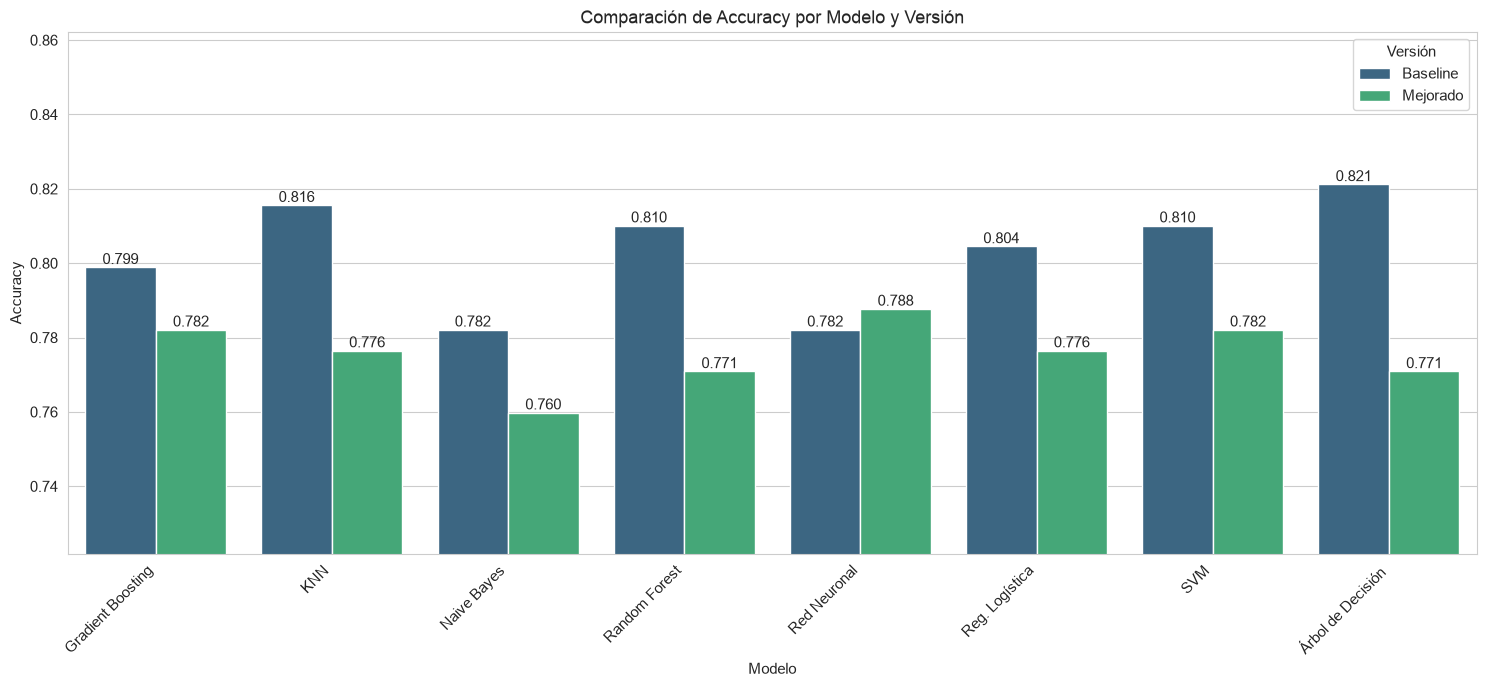

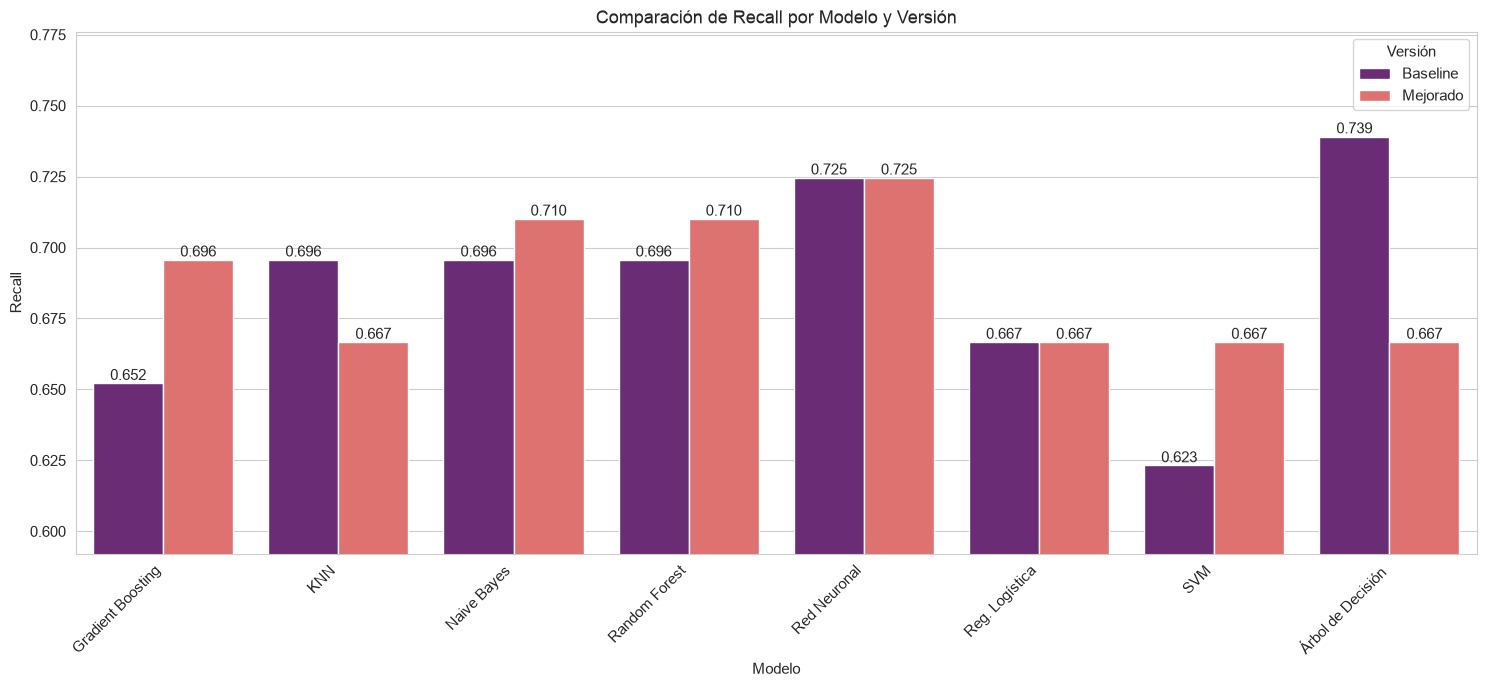

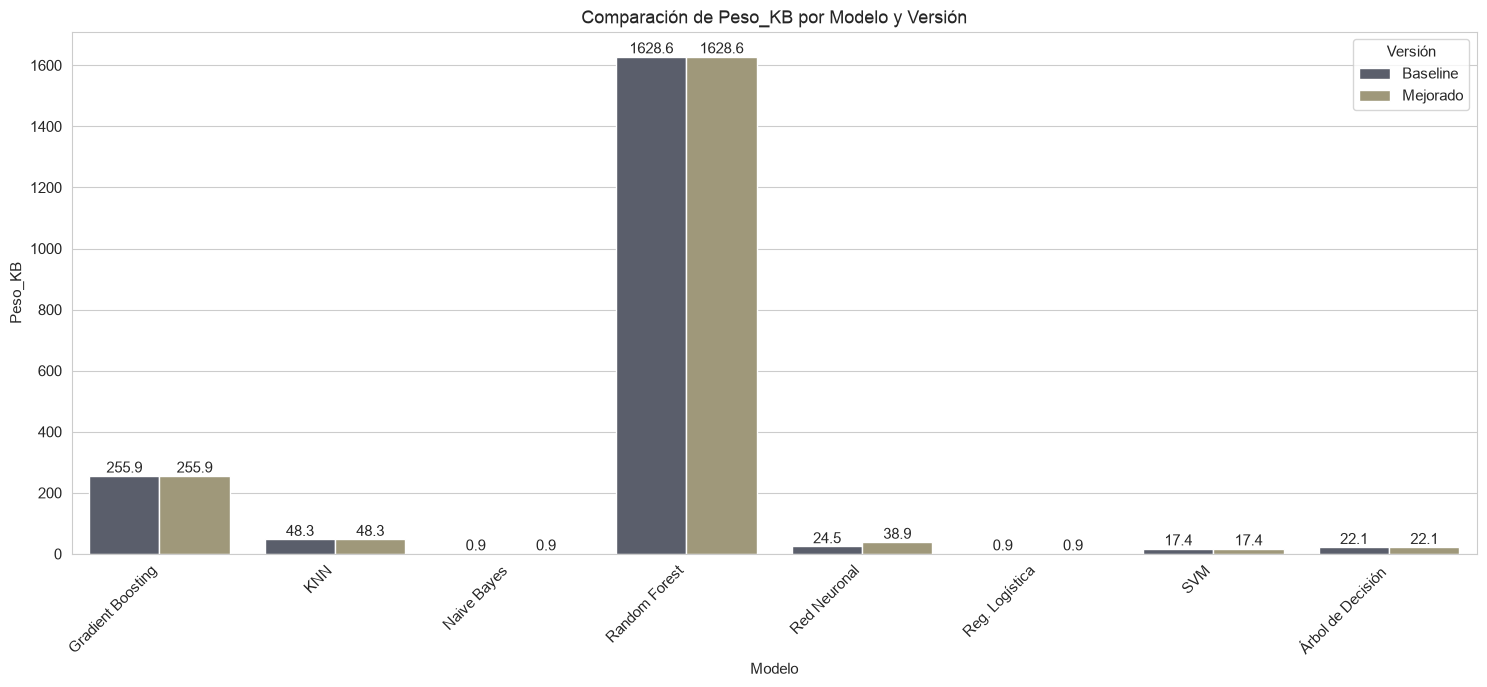

In [29]:
for metric, palette, fmt, fname in [("Accuracy", "viridis", "%.3f", "07_cmp_accuracy.png"),
                                    ("Recall", "magma", "%.3f", "08_cmp_recall.png"),
                                    ("Peso_KB", "cividis", "%.1f", "09_cmp_peso.png")]:
    plt.figure(figsize=(15, 7))
    ax = sns.barplot(x="Modelo", y=metric, hue="Versión", data=full_comparative_df, palette=palette)
    ax.set_title(f"Comparación de {metric} por Modelo y Versión")
    plt.xticks(rotation=45, ha="right")
    if metric != "Peso_KB":
        ax.set_ylim(full_comparative_df[metric].min()*0.95, full_comparative_df[metric].max()*1.05)
    for cont in ax.containers:
        ax.bar_label(cont, fmt=fmt)
    plt.tight_layout(); plt.savefig(OUT_DIR / fname, dpi=120); plt.show()

## Conclusiones finales

El bloque siguiente reporta automáticamente el mejor modelo por **Recall**.

In [30]:
win = comparative_final.iloc[0]
print(f"Mejor modelo por Recall: {win['Modelo']} (Mejorado) -> "
      f"Recall={win['Recall']:.4f} | F1={win['F1']:.4f} | Accuracy={win['Accuracy']:.4f} | AUC={win['AUC']:.4f}")
print(f"\nVariables predictivas usadas en 'mejorado': {selected_features}")

Mejor modelo por Recall: Red Neuronal (Mejorado) -> Recall=0.7246 | F1=0.7246 | Accuracy=0.7877 | AUC=0.8593

Variables predictivas usadas en 'mejorado': ['sex', 'pclass', 'fare']


- **Mejor modelo en Recall:** ver el bloque anterior (generado desde los resultados). El objetivo
  clínico/rescate es **maximizar el recall** (detectar a quien sí podía sobrevivir).
- **Comparación con el Cáncer de Mama:** el Titanic presenta **mayor dificultad de clasificación** que
  el WBCD — las variables tienen menor correlación lineal con el target (la mayor, `sex`, ≈ 0.54, frente
  a > 0.7 en varias del WBCD), lo que explica métricas generalmente más bajas y por qué el umbral de
  selección bajó de 0.4 a 0.2.
- **Variable más predictiva:** el **sexo**, reflejando la política de evacuación *"mujeres y niños
  primero"* — el ML descubre así un **sesgo histórico** presente en los datos.
- **Naive Bayes** tuvo el peor desempeño porque su supuesto de independencia choca con la correlación
  `pclass`/`fare`.
- **Recall vs Accuracy:** en contextos de desequilibrio, un accuracy alto puede esconder muchos Falsos
  Negativos; por eso priorizamos el recall de la clase positiva.

---
## 🔧 Aplicación Profesional — Learning by Doing

> *Cada integrante del equipo describe en 2-3 líneas cómo aplicaría los contenidos de esta semana en su
> entorno laboral o proyecto de titulación.*

**Jorge Armando Quizamánchuro Fuel:**
En Psico Platform, este flujo de preprocesamiento del Titanic — donde la mayor parte del esfuerzo va en
limpiar, imputar y codificar variables heterogéneas — es análogo al reto que enfrento con datos de
cuestionarios psicológicos: campos de texto libre, escalas Likert, variables faltantes y categorías que
deben codificarse con criterio clínico antes de entrenar cualquier modelo de detección de riesgo.

**Jonathan Fabricio Gualli Ramírez:**
_[PLACEHOLDER — completar manualmente]_

**Raúl Marcelo Salazar Gamboa:**
_[PLACEHOLDER — completar manualmente]_